In [1]:
# ==============================
# 1. IMPORTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [4]:
import shap

In [5]:
# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_excel(r"C:\Users\asus\Downloads\Churn_pred\Telco_customer_churn.xlsx")

In [6]:
print("Shape:", df.shape)
print(df.head())
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Mo

In [7]:
# ==============================
# 3. DATA CLEANING
# ==============================
# Drop irrelevant / location-based / leakage columns
df = df.drop(columns=[
    'CustomerID', 'Lat Long', 'Zip Code', 'City', 'State', 'Country',
    'Churn Reason', 'Count'
], errors='ignore')

In [8]:
df.columns = df.columns.str.replace(' ', '_')

In [9]:
# Fix Total_Charges — sometimes read as string due to spaces
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df['Total_Charges'] = df['Total_Charges'].fillna(df['Total_Charges'].median())

In [10]:
# ==============================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================
print("\n--- Starting Exploratory Data Analysis ---")


--- Starting Exploratory Data Analysis ---


C:\Users\asus\AppData\Local\Temp\ipykernel_28412\2711399790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn_Value', palette='viridis')


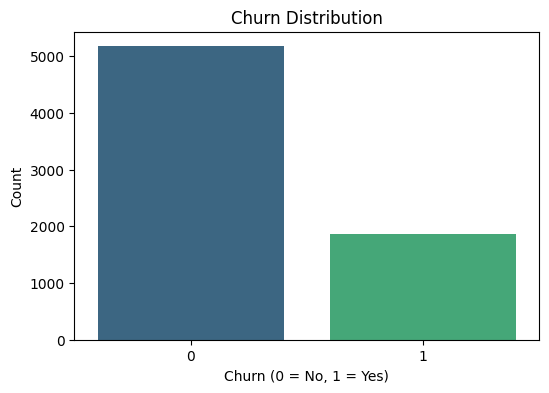

In [11]:
# a. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn_Value', palette='viridis')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [12]:
# b. Categorical Features vs Churn
categorical_cols = ['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 
                    'Contract', 'Payment_Method', 'Internet_Service']
existing_cat_cols = [c for c in categorical_cols if c in df.columns]

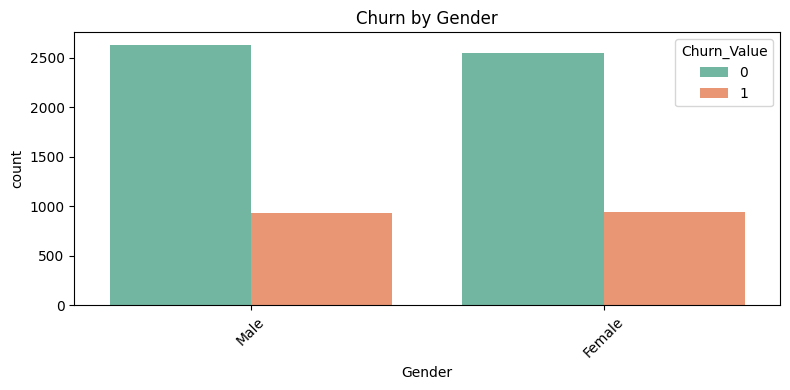

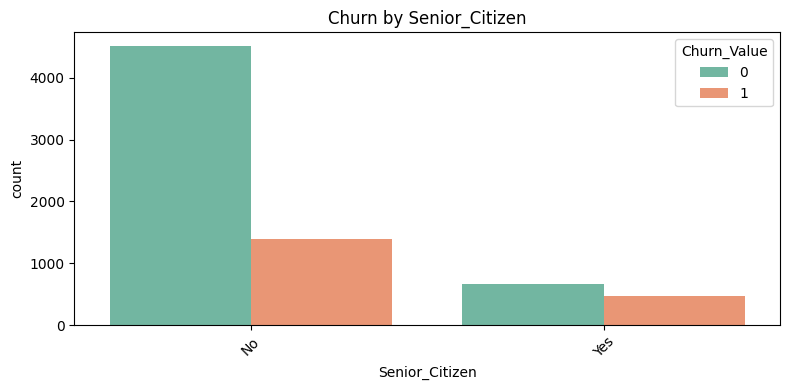

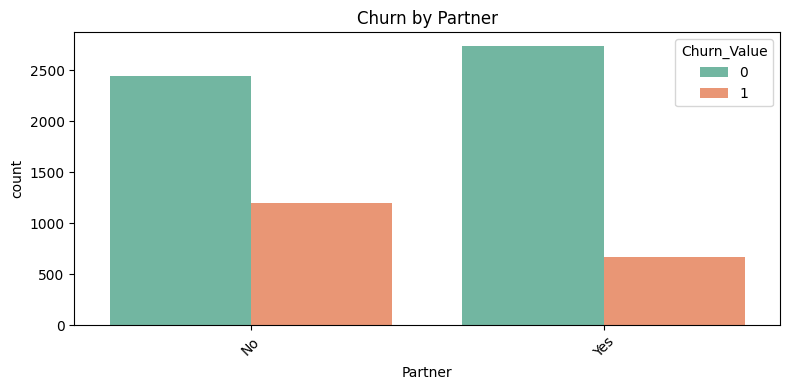

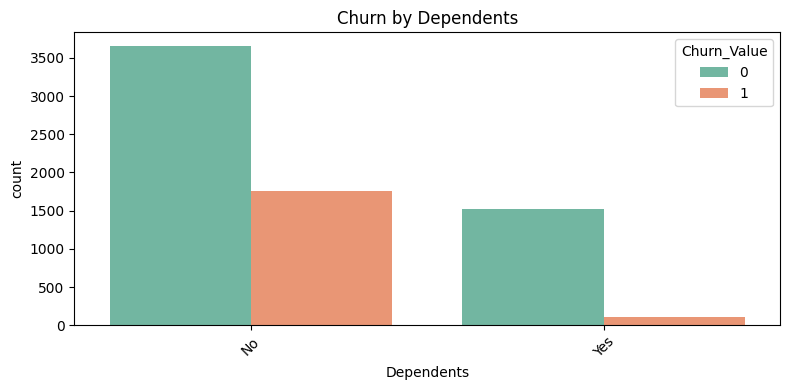

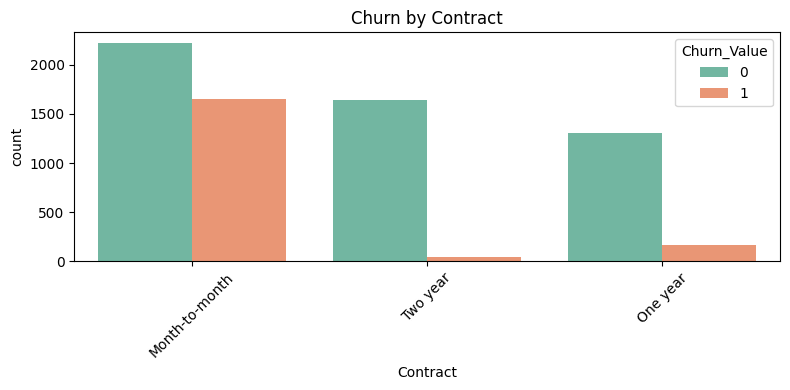

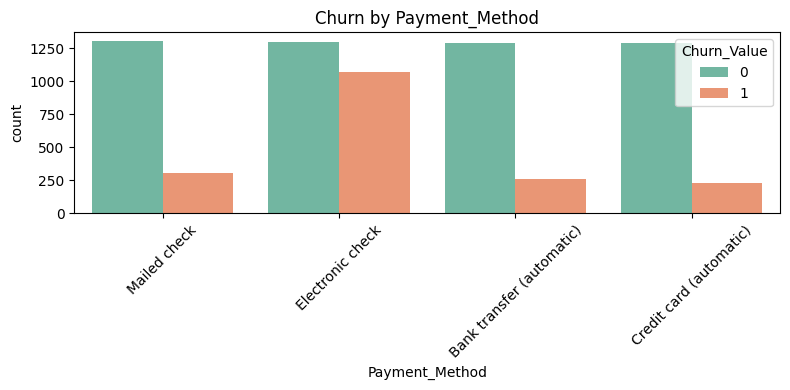

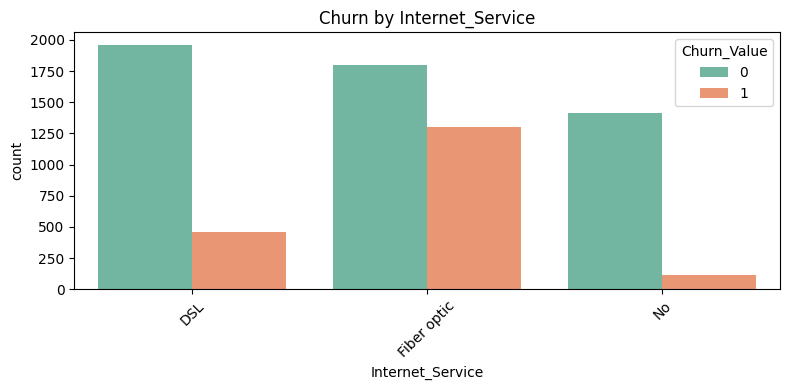

In [13]:
for col in existing_cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='Churn_Value', palette='Set2')
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [14]:
# c. Numerical Features Distribution
numerical_cols = ['Tenure_Months', 'Monthly_Charges', 'Total_Charges']
existing_num_cols = [c for c in numerical_cols if c in df.columns]

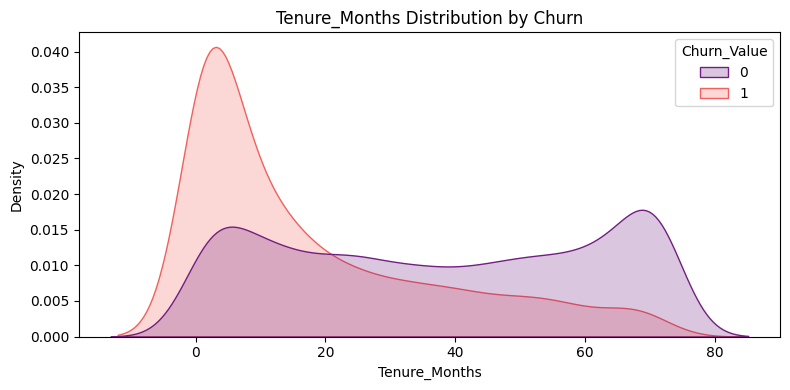

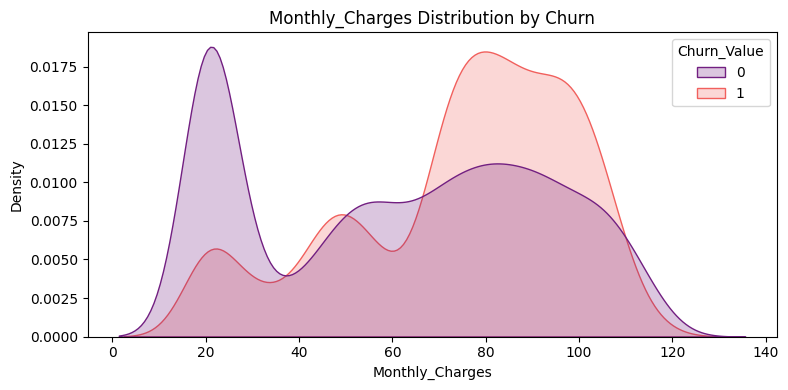

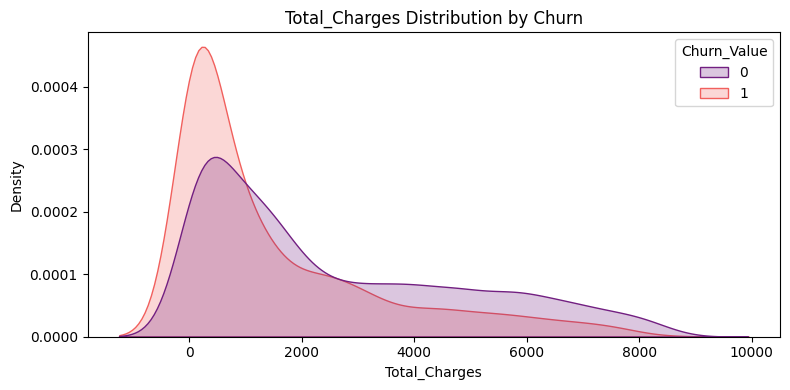

In [15]:
for col in existing_num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue='Churn_Value', fill=True, palette='magma', common_norm=False)
    plt.title(f'{col} Distribution by Churn')
    plt.tight_layout()
    plt.show()

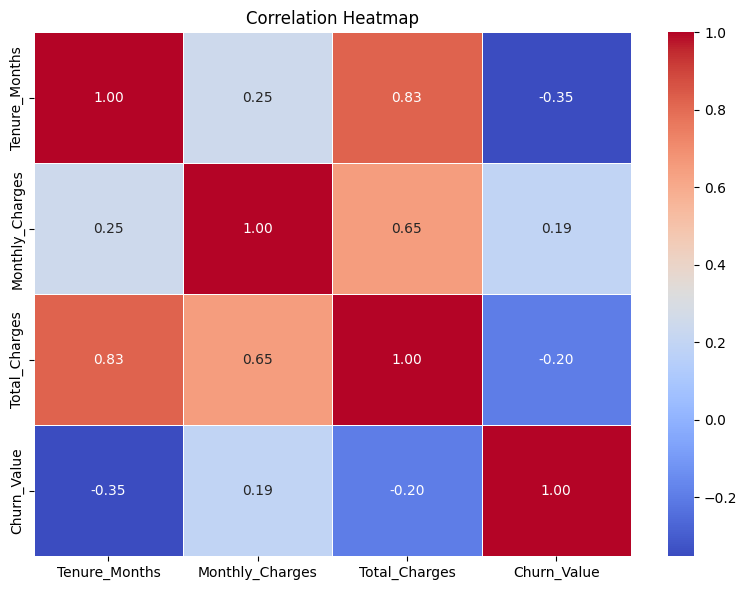

In [16]:
# d. Correlation Heatmap for Numerical Features
if existing_num_cols:
    plt.figure(figsize=(8, 6))
    correlation_matrix = df[existing_num_cols + ['Churn_Value']].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

In [17]:
# ==============================
# 5. FEATURE / TARGET SPLIT
# Drop leakage columns:
#   - Churn_Label : string version of target
#   - Churn_Score : derived directly from churn probability
#   - Churn_Value : the target itself
# ==============================
X = df.drop(['Churn_Label', 'Churn_Value', 'Churn_Score'], axis=1, errors='ignore')
y = df['Churn_Value']

In [18]:
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")


Target distribution:
Churn_Value
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [19]:
# ==============================
# 6. ENCODING
# drop_first=False for full interpretability across all models
# ==============================
X = pd.get_dummies(X, drop_first=False)
feature_names = X.columns.tolist()

In [20]:
# ==============================
# 7. TRAIN / TEST SPLIT
# stratify=y ensures same churn ratio in both sets
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# ==============================
# 8. SCALING
# Fit only on train — transform both
# Keep as DataFrame to preserve feature names (needed for SHAP)
# ==============================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_names)

In [22]:
# ==============================
# 9. SMOTE (on train only — never touch test)
# Applied after scaling so synthetic points are in the same feature space
# ==============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [23]:
print(f"\nClass distribution BEFORE SMOTE: {dict(y_train.value_counts())}")
print(f"Class distribution AFTER  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}")


Class distribution BEFORE SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
Class distribution AFTER  SMOTE: {0: np.int64(4139), 1: np.int64(4139)}


In [24]:
# ==============================
# 10. RANDOM FOREST
# ==============================
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]

In [26]:
print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


========== Random Forest ==========
Accuracy : 0.7814052519517388
ROC-AUC  : 0.837473197447622
[[873 162]
 [146 228]]
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.61      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [27]:
# ==============================
# 11. XGBOOST
# eval_metric set explicitly to suppress warnings
# use_label_encoder=False for compatibility with newer XGBoost versions
# ==============================
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:14:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb  = xgb.predict_proba(X_test_scaled)[:, 1]

In [29]:
print("\n========== XGBoost ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


========== XGBoost ==========
Accuracy : 0.7764371894960965
ROC-AUC  : 0.8495750342297657
[[846 189]
 [126 248]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [30]:
# ==============================
# 12. LOGISTIC REGRESSION 
# ==============================
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [32]:
print("\n========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


========== Logistic Regression ==========
Accuracy : 0.7494677075940384
ROC-AUC  : 0.8464878968715286
[[764 271]
 [ 82 292]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [33]:
# ==============================
# 13. ADABOOST CLASSIFIER 
# ==============================
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_sm, y_train_sm)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [34]:
y_pred_ada = ada.predict(X_test_scaled)
y_prob_ada = ada.predict_proba(X_test_scaled)[:, 1]

In [35]:
print("\n========== AdaBoost Classifier ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_ada))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_ada))
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))


========== AdaBoost Classifier ==========
Accuracy : 0.7579843860894251
ROC-AUC  : 0.8485623498411222
[[786 249]
 [ 92 282]]
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



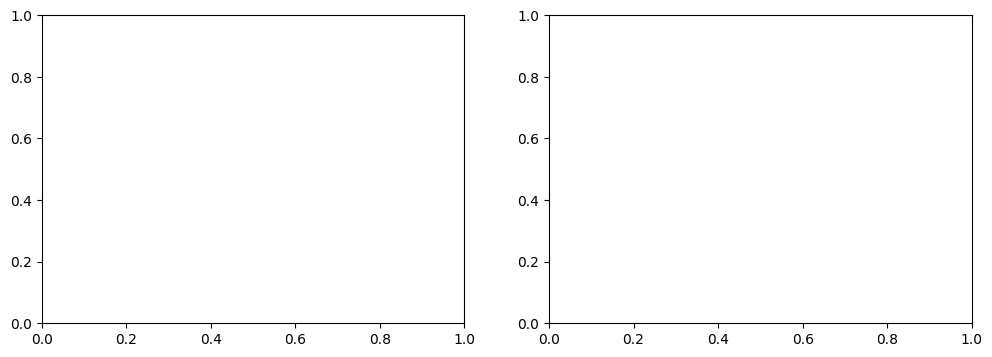

In [36]:
# ==============================
# 14. CONFUSION MATRICES (side by side)
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

In [39]:
for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb,y_pred_lr,y_pred_ada],
    ["Random Forest", "XGBoost","Logistic Regression","ADABOOST CLASSIFIER"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

In [40]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
# ==============================
# 15. ROC CURVE COMPARISON
# ==============================
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)

In [42]:
auc_rf  = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_ada = roc_auc_score(y_test, y_prob_ada)

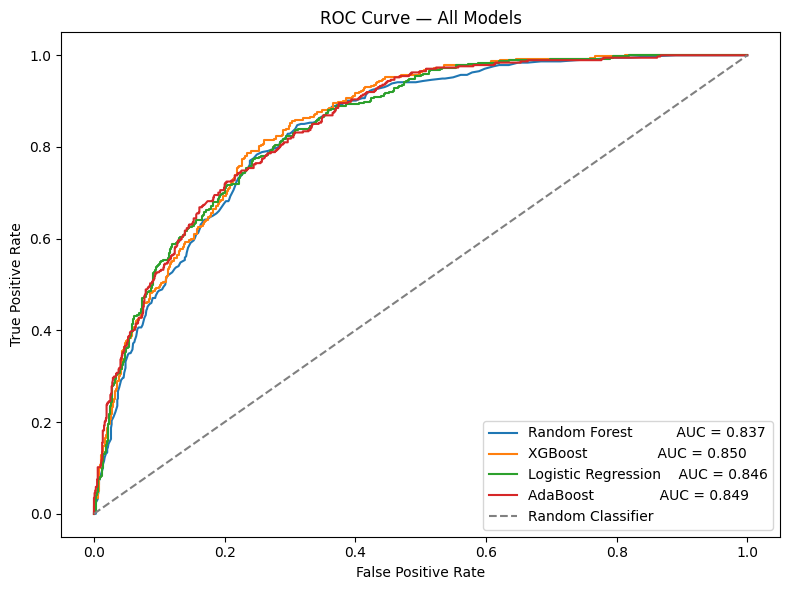

In [43]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest          AUC = {auc_rf:.3f}")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost                AUC = {auc_xgb:.3f}")
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression    AUC = {auc_lr:.3f}")
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost               AUC = {auc_ada:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# ==============================
# 14. FEATURE IMPORTANCE (Random Forest)
# ==============================
feat_imp = pd.Series(rf.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

In [45]:
print("\nTop 10 Important Features (Random Forest):")
print(feat_imp.head(10))


Top 10 Important Features (Random Forest):
Contract_Month-to-month            0.091892
Tenure_Months                      0.078132
Total_Charges                      0.066963
Monthly_Charges                    0.061199
CLTV                               0.058671
Latitude                           0.055179
Longitude                          0.054044
Online_Security_No                 0.044866
Tech_Support_No                    0.041243
Payment_Method_Electronic check    0.035612
dtype: float64


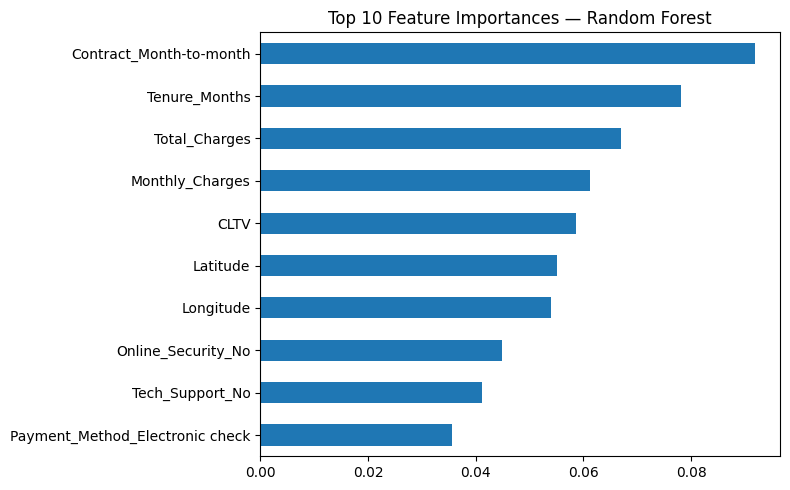

In [46]:
plt.figure(figsize=(8, 5))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
# ==============================
# 15. SHAP ANALYSIS
# TreeExplainer is exact and fast for both RF and XGBoost.
# We use XGBoost for SHAP (typically sharper explanations).
# FIX: Compute SHAP on the FULL test set (not a 200-row sample).
#      This prevents IndexError in Section 16 when high-risk customers
#      fall outside the sampled 200 rows.
# For plots we use a 200-row subset so the charts remain readable.
# ==============================
explainer   = shap.TreeExplainer(xgb)

In [48]:
# Full test SHAP values — used for retention insights (Section 16)
X_test_reset = X_test_scaled.reset_index(drop=True)
shap_values  = explainer.shap_values(X_test_reset)   # shape: (n_test, n_features)

In [49]:
# 200-row subset — used only for summary plots (readability)
plot_idx     = np.random.RandomState(42).choice(len(X_test_reset), 200, replace=False)
X_plot       = X_test_reset.iloc[plot_idx]
shap_plot    = shap_values[plot_idx]

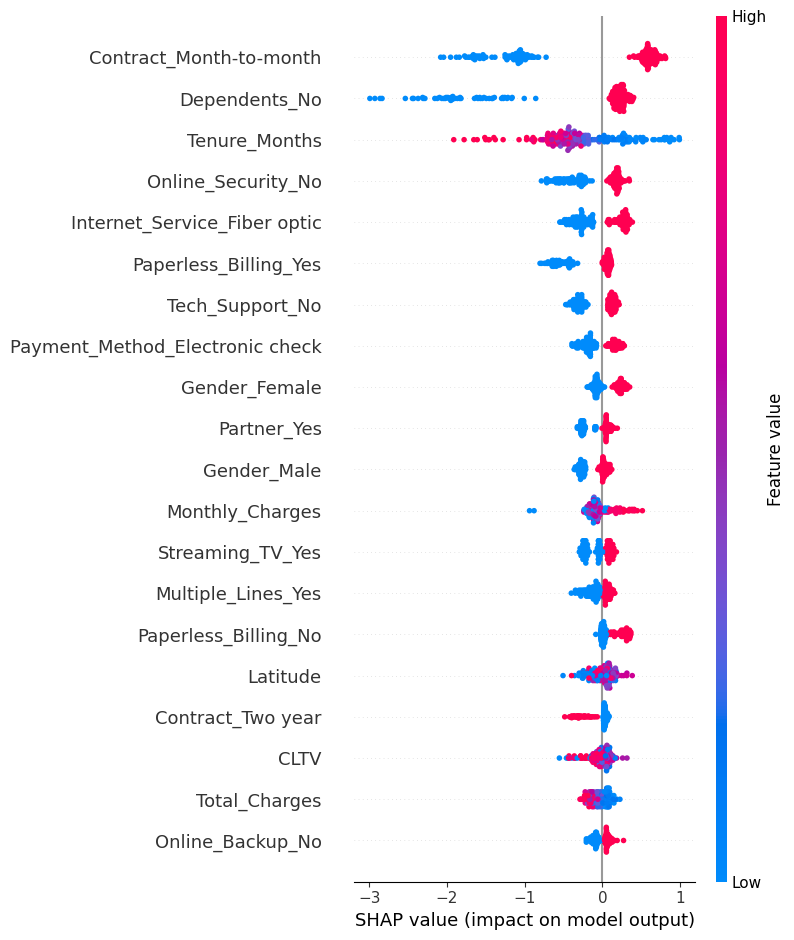

In [50]:
# Summary beeswarm plot — shows feature impact direction and magnitude
shap.summary_plot(shap_plot, X_plot, plot_type="dot")

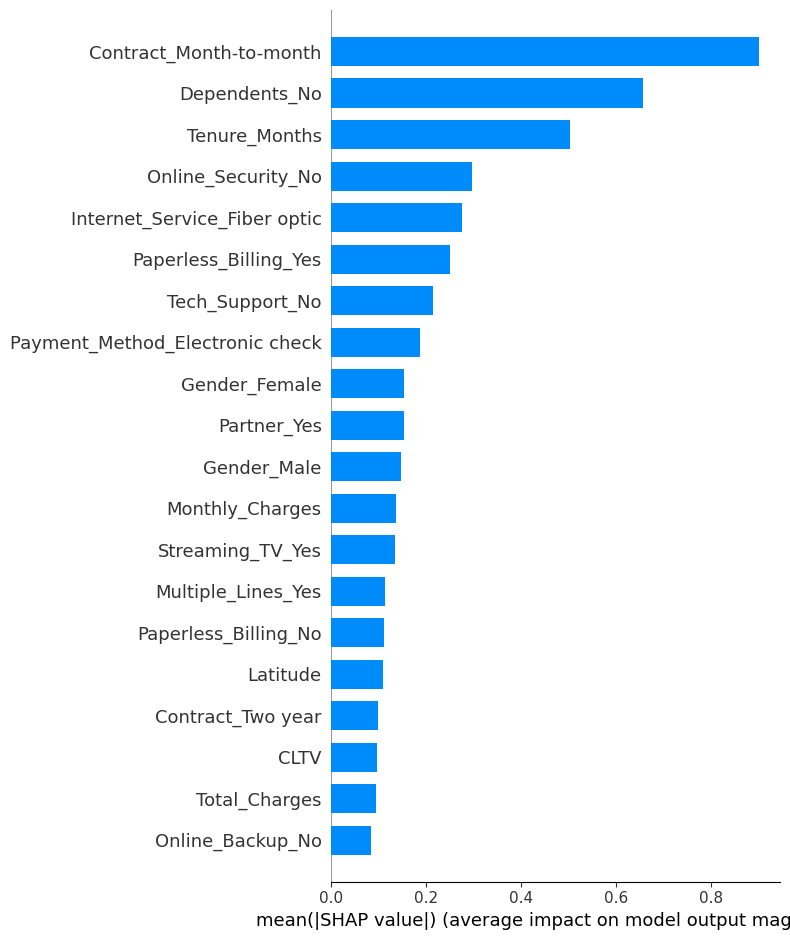

In [51]:
# Bar plot — mean absolute SHAP value per feature
shap.summary_plot(shap_plot, X_plot, plot_type="bar")

In [52]:
# ==============================
# 16. CROSS VALIDATION (XGBoost Pipeline)
# ImbPipeline ensures SMOTE runs inside each fold — no leakage.
# StratifiedKFold is the default for classification in cross_val_score.
# ==============================
cv_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('xgb',    XGBClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=5,
                    use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42,
                    n_jobs=-1
               ))
])

In [53]:
cv_scores = cross_val_score(cv_pipeline, X, y, cv=5, scoring='roc_auc')

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:16:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:16:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:16:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:16:13] WARNING: C:\actions-r

In [54]:
print("\n========== Cross Validation (XGBoost) ==========")
print("Fold AUC Scores :", cv_scores)
print("Mean  CV AUC    :", round(cv_scores.mean(), 4))
print("Std   CV AUC    :", round(cv_scores.std(),  4))


========== Cross Validation (XGBoost) ==========
Fold AUC Scores : [0.82887184 0.87422047 0.84279625 0.84992217 0.85411146]
Mean  CV AUC    : 0.85
Std   CV AUC    : 0.0148


==============================
17. ACTIONABLE CUSTOMER RETENTION INSIGHTS
Identify high-risk customers from the test set.
Use SHAP to find the top churn driver for each at-risk customer.
Translate those drivers into business retention actions.
==============================

In [55]:
# --- Map top SHAP drivers to retention strategies ---
RETENTION_ACTIONS = {
    'Contract':          "Offer a discounted 1- or 2-year contract to lock in the customer.",
    'Tenure':            "Assign a dedicated account manager to new/short-tenure customers.",
    'Monthly_Charges':   "Provide a personalised discount or bundle upgrade to reduce bill.",
    'Tech_Support':      "Proactively reach out with free technical support or onboarding.",
    'Internet_Service':  "Upgrade internet plan or offer a free speed boost trial.",
    'Online_Security':   "Offer a free 3-month online security add-on.",
    'Payment_Method':    "Incentivise switch to auto-pay with a small monthly discount.",
    'Total_Charges':     "Review billing history and offer a goodwill credit if anomalies found.",
    'Dependents':        "Promote family/multi-line plans with bundled discounts.",
    'Partner':           "Offer couples or household bundling deals.",
}

In [56]:
def get_retention_action(feature):
    """Return a retention action for the most relevant feature keyword."""
    for key, action in RETENTION_ACTIONS.items():
        if key.lower() in feature.lower():
            return action
    return "Conduct a personalised retention call to understand dissatisfaction."

In [57]:
# Build high-risk customer table (churn probability > 0.7)
# FIX: Use X_test_reset (positional index 0..n) so it aligns with shap_values rows.
risk_df = X_test_reset.copy()
risk_df['Churn_Probability'] = y_prob_xgb
risk_df['Predicted_Churn']   = y_pred_xgb
risk_df['Actual_Churn']      = y_test.values

In [58]:
high_risk = risk_df[risk_df['Churn_Probability'] > 0.7].copy()
print(f"\nHigh-risk customers (churn probability > 70%): {len(high_risk)}")


High-risk customers (churn probability > 70%): 229


In [59]:
# FIX: high_risk.index is now positional (0-based), matching shap_values rows exactly.
shap_high = shap_values[high_risk.index]   # shape: (n_high_risk, n_features)

In [60]:
# Build insight report
insights = []
for pos, (idx, row) in enumerate(high_risk.iterrows()):
    top_feature_idx  = np.argmax(np.abs(shap_high[pos]))
    top_feature_name = feature_names[top_feature_idx]
    top_shap_value   = shap_high[pos][top_feature_idx]
    action           = get_retention_action(top_feature_name)

    insights.append({
        'Customer_Index'     : idx,
        'Churn_Probability'  : round(row['Churn_Probability'], 3),
        'Top_Churn_Driver'   : top_feature_name,
        'SHAP_Impact'        : round(float(top_shap_value), 4),
        'Recommended_Action' : action
    })

In [61]:
insights_df = pd.DataFrame(insights)

In [62]:
print("\n========== Customer Retention Insights (Top 20 High-Risk) ==========")
pd.set_option('display.max_colwidth', 80)
print(insights_df.head(20).to_string(index=False))


========== Customer Retention Insights (Top 20 High-Risk) ==========
 Customer_Index  Churn_Probability        Top_Churn_Driver  SHAP_Impact                                                Recommended_Action
              1              0.875 Contract_Month-to-month       0.6419 Offer a discounted 1- or 2-year contract to lock in the customer.
             13              0.807 Contract_Month-to-month       0.6376 Offer a discounted 1- or 2-year contract to lock in the customer.
             27              0.931 Contract_Month-to-month       0.5412 Offer a discounted 1- or 2-year contract to lock in the customer.
             29              0.862 Contract_Month-to-month       0.6551 Offer a discounted 1- or 2-year contract to lock in the customer.
             34              0.901 Contract_Month-to-month       0.6574 Offer a discounted 1- or 2-year contract to lock in the customer.
             38              0.850           Tenure_Months       0.7939 Assign a dedicated account man

In [63]:
# --- Summary: Most common churn drivers across all high-risk customers ---
print("\n========== Most Common Churn Drivers Across High-Risk Segment ==========")
driver_counts = insights_df['Top_Churn_Driver'].value_counts().head(5)
print(driver_counts)


========== Most Common Churn Drivers Across High-Risk Segment ==========
Top_Churn_Driver
Contract_Month-to-month    166
Tenure_Months               59
Online_Security_No           3
Dependents_No                1
Name: count, dtype: int64


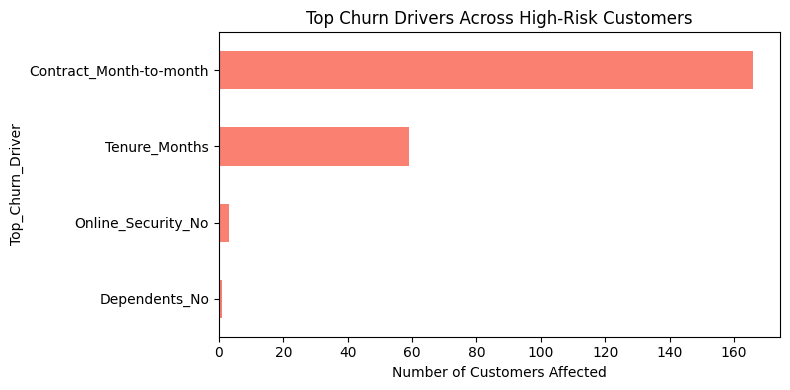

In [64]:
plt.figure(figsize=(8, 4))
driver_counts.plot(kind='barh', color='salmon')
plt.title("Top Churn Drivers Across High-Risk Customers")
plt.xlabel("Number of Customers Affected")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


========== Priority Retention Actions for Business Team ==========
1. [Contract_Month-to-month] → Offer a discounted 1- or 2-year contract to lock in the customer.
2. [Tenure_Months] → Assign a dedicated account manager to new/short-tenure customers.
3. [Online_Security_No] → Offer a free 3-month online security add-on.
4. [Dependents_No] → Promote family/multi-line plans with bundled discounts.
ROC-AUC Score: 0.8495750342297657


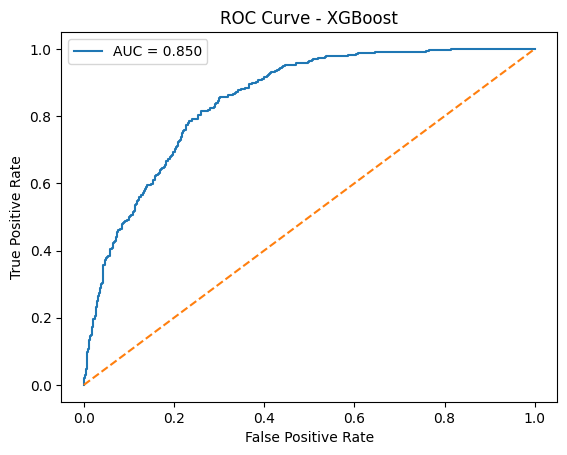

In [69]:
# --- Print top 5 prioritised retention actions ---
print("\n========== Priority Retention Actions for Business Team ==========")
top_drivers = driver_counts.index.tolist()
for rank, driver in enumerate(top_drivers, 1):
    action = get_retention_action(driver)
    print(f"{rank}. [{driver}] → {action}")
y_prob = y_prob_xgb
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()
